In [7]:
import os
import json
from ast import literal_eval
from datetime import datetime, timedelta

import pandas as pd

import numpy as np
from IPython.display import clear_output

from python_utilities.db_connection import DbConnection


In [8]:
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')

INFO [2026-05-07 14:47:21] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [11]:
# start and end is included
# start_date = "2026-05-01"
# end_date = "2026-05-06"
start_date = "2026-04-01"
end_date = "2026-05-01"

In [12]:
all_egvp_messages = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_tickets
    WHERE created_at >= '{start_date}'
    AND created_at < '{end_date}'
    AND source_type = 'egvp'
""")

In [13]:
print("Total messages:", len(all_egvp_messages))
print("Unique tickets:", all_egvp_messages['ticket_uuid'].nunique())
# ticket uuid is null
print("Messages with null ticket uuid:", all_egvp_messages['ticket_uuid'].isnull().sum())
print("Date max: {}, date min: {}".format(all_egvp_messages['created_at'].max(), all_egvp_messages['created_at'].min()))

Total messages: 11071
Unique tickets: 11071
Messages with null ticket uuid: 0
Date max: 2026-04-30 22:44:00, date min: 2026-04-01 01:44:00


### get attachments for egvp tickets -> basically the documents

In [14]:
egvp_attachments = analytics_db.sql_to_df(f"""
    SELECT la.*, lt.egvp_id
    FROM llm_attachments la
    LEFT JOIN llm_tickets lt
    ON la.ticket_uuid = lt.ticket_uuid
    WHERE la.created_at >= '{start_date}'
    AND la.created_at < '{end_date}'
""")

In [15]:
egvp_attachments

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id
0,3384699,0bf36296-6394-5b5f-8c5f-c04f871bb9ae,26492337373212-1,18205510.0,2.649234e+13,processed,Screenshot_2026-03-26-00-53-41-623_com.android...,jpg,2026-04-01 07:18:17,2026-04-01 00:06:42,ocr_source_files/2026-04-01/zendesk_id_1820551...,pair-data-engineering-new,None
1,3384700,0bf36296-6394-5b5f-8c5f-c04f871bb9ae,26492337373212-2,18205510.0,2.649234e+13,processed,Screenshot_2026-03-26-01-02-03-109_com.android...,jpg,2026-04-01 07:18:17,2026-04-01 00:06:42,ocr_source_files/2026-04-01/zendesk_id_1820551...,pair-data-engineering-new,None
2,3384701,b67081fa-cdb5-5e73-aa9c-3e99b3e9dafc,26492305203868-1,18202983.0,2.649231e+13,processed,IMG_6300.png,png,2026-04-01 07:18:17,2026-04-01 00:08:07,ocr_source_files/2026-04-01/zendesk_id_1820298...,pair-data-engineering-new,None
3,3384702,dd58d894-8012-59c6-b1d0-1570f3d3e080,26492361630492-1,18205516.0,2.649236e+13,processed,1000036070-id-9fec4d66-c1db-4596-a79f-560131ef...,png,2026-04-01 07:18:17,2026-04-01 00:11:56,ocr_source_files/2026-04-01/zendesk_id_1820551...,pair-data-engineering-new,None
4,3384703,f880c894-d89d-5062-91b1-1485e8144bfc,26492408167964-1,18205513.0,2.649241e+13,processed,IMG_8481.jpeg,jpeg,2026-04-01 07:18:17,2026-04-01 00:11:45,ocr_source_files/2026-04-01/zendesk_id_1820551...,pair-data-engineering-new,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
134362,3519061,dda69656-f422-5ef8-b8e4-c69fc81b62aa,27158926104860-1,18458160.0,2.715893e+13,processed,1000145782.jpg,jpg,2026-05-01 01:18:40,2026-04-30 23:22:06,ocr_source_files/2026-04-30/zendesk_id_1845816...,pair-data-engineering-new,None
134363,3519062,dda69656-f422-5ef8-b8e4-c69fc81b62aa,27158926104860-2,18458160.0,2.715893e+13,processed,1000145783.jpg,jpg,2026-05-01 01:18:31,2026-04-30 23:22:06,ocr_source_files/2026-04-30/zendesk_id_1845816...,pair-data-engineering-new,None
134364,3519063,dbd342fe-5c1d-590b-bc31-b0caee1def61,27158986197276-1,18461183.0,2.715899e+13,processed,transaction-statement_052c9eaa-8979-e33a-08c0-...,pdf,2026-05-01 01:18:33,2026-04-30 23:27:07,ocr_source_files/2026-04-30/zendesk_id_1846118...,pair-data-engineering-new,None
134365,3519064,09f37e2e-79a3-5478-8b1d-8750230e6358,27159083472284-1,18391062.0,2.715908e+13,processed,1000240953.jpg,jpg,2026-05-01 01:18:41,2026-04-30 23:39:17,ocr_source_files/2026-04-30/zendesk_id_1839106...,pair-data-engineering-new,None


### only get attachments from egvp

In [16]:
egvp_attachments = egvp_attachments[~egvp_attachments['attachment_id'].str.contains('-')]

In [17]:
egvp_attachments.ticket_uuid.nunique()

11071

###below should be true

In [18]:
egvp_attachments.ticket_uuid.dropna().unique().sort() == all_egvp_messages['ticket_uuid'].dropna().unique().sort()

True

# Automation percentage analysis

### 1) Incoming egvp attachment grouped by date

<Axes: title={'center': 'Daily Incoming EGVP Attachments'}, xlabel='created_at'>

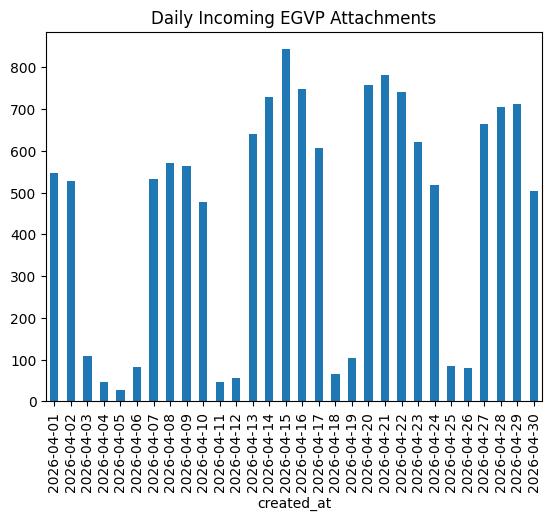

In [19]:
daily_incoming_egvp_attachments = egvp_attachments.groupby(egvp_attachments['created_at'].dt.date).size()
daily_incoming_egvp_attachments.plot(kind='bar', title='Daily Incoming EGVP Attachments')

### 2)Check statuses

In [20]:
import plotly.express as px

daily_status = (
    egvp_attachments
    .groupby([egvp_attachments['created_at'].dt.date, 'status'])
    .size()
    .reset_index(name='count')
    .rename(columns={'created_at': 'day'})
)
daily_status['day'] = daily_status['day'].astype(str)

fig = px.bar(
    daily_status,
    x='day',
    y='count',
    color='status',
    title='Daily Incoming EGVP Attachments by Status',
    labels={'day': 'Day', 'count': 'Count', 'status': 'Status'},
    text='count',
)
fig.update_layout(
    template='plotly_white',
    barmode='stack',
    width=1000,
    height=500,
    legend_title_text='',
)
fig.show()

### 3) Get Predictions for EGVP attachments

In [21]:
# get predictions for the corresponding attachments
print("Number of unique attachments:", egvp_attachments['attachment_id'].nunique())

Number of unique attachments: 13496


In [22]:
egvp_attachment_preds = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_attachments_predictions
    WHERE attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_attachments.attachment_id.unique()])})
""")

In [23]:
egvp_attachments.attachment_id.nunique()

13496

In [24]:
egvp_attachment_preds.attachment_id.nunique()

12403

In [25]:
print("Among {} unique attachments, {} have predictions.".format(
    egvp_attachments.attachment_id.nunique(),
    egvp_attachment_preds.attachment_id.nunique()
))

Among 13496 unique attachments, 12403 have predictions.


In [26]:
processed_atch_counts = egvp_attachments[egvp_attachments['status'] == 'processed'].shape[0]
print(egvp_attachment_preds.attachment_id.nunique()==processed_atch_counts) # should be true

True


In [27]:
# Reshape long-format predictions -> one row per attachment_id with
# columns like ladung_class_prob, ladung_slug, pfub_debtor_name, etc.

preds = egvp_attachment_preds.copy()

# strip stray single-quotes that wrap the stored values
preds['value'] = preds['value'].astype(str).str.replace("'", "", regex=False)

# build wide column name: "<short_model>_<subtype>"
preds['col'] = (
    preds['model_name'].str.replace('aftercourt_classification_', '', regex=False)
    + '_' + preds['subtype']
)

wide_attch_preds = (
    preds.pivot_table(
        index='attachment_id',
        columns='col',
        values='value',
        aggfunc='first',  # in case of duplicate (attachment_id, col)
    )
    .reset_index()
)
wide_attch_preds.columns.name = None

# cast probability columns to float and fill missing
prob_cols = [c for c in wide_attch_preds.columns if c.endswith('_class_prob')]
for c in prob_cols:
    wide_attch_preds[c] = pd.to_numeric(wide_attch_preds[c], errors='coerce').fillna(-1)

# fill remaining (string) columns with 'none'
str_cols = [c for c in wide_attch_preds.columns if c not in prob_cols + ['attachment_id']]
wide_attch_preds[str_cols] = wide_attch_preds[str_cols].fillna('none')

wide_attch_preds


,attachment_id,ladung_aftercourt_type,ladung_class_pred,ladung_class_prob,ladung_debtor_name,ladung_judicial_summon_date,ladung_slug,pfub_aftercourt_type,pfub_class_pred,pfub_class_prob,pfub_creditor_name,pfub_debtor_name,pfub_erlass_egvp_creditor_name,pfub_erlass_egvp_debtor_name,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,pfub_erlass_egvp_slug,pfub_slug
0,58103584,ladung_va,True,1.00,Herrn Steffen Röttsches,28-04-2026,184883682512,pfub_erlass,False,0.00000,none,none,none,none,none,none,none,none
1,58106384,ladung_va,False,0.03,none,none,none,pfub_erlass,False,0.00000,none,none,none,none,none,none,none,none
2,58122067,ladung_va,False,0.00,none,none,none,pfub_erlass,True,0.85131,none,Zimmer,none,none,none,none,none,158118135512
3,58122197,ladung_va,False,0.09,none,none,none,pfub_erlass,False,0.00000,none,none,none,none,none,none,none,none
4,58122198,ladung_va,False,0.07,none,none,none,pfub_erlass,False,0.01000,none,none,none,none,none,none,none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12398,61574050,ladung_va,False,0.02,none,none,none,pfub_erlass,False,0.02000,none,none,none,none,False,False,none,none
12399,61574053,ladung_va,False,0.25,none,none,none,pfub_erlass,False,0.03000,none,none,none,none,True,False,none,none
12400,61574054,ladung_va,False,0.10,none,none,none,pfub_erlass,False,0.02000,none,none,none,none,False,False,none,none
12401,61575761,ladung_va,False,0.00,none,none,none,pfub_erlass,False,0.02000,none,none,none,none,False,False,none,none


In [28]:
print(wide_attch_preds.attachment_id.nunique())

12403


### 4) Automation Calculation for EGVP attachments using preds

In [29]:
def is_all_params_extracted_ladung(slug, debtor_name, judicial_summon_date):
    if slug and debtor_name and judicial_summon_date and slug not in ['','none'] and debtor_name not in ['','none'] and judicial_summon_date not in ['','none']:
        return True
    return False

def is_all_params_extracted_pfub(slug, debtor_name):
    if slug and debtor_name and slug not in ['','none'] and debtor_name not in ['','none']:
        return True
    return False

def is_automated_ladung(row):
    is_ladung = row['ladung_class_prob'] >= 0.95
    is_all_param_extracted = is_all_params_extracted_ladung(
        row['ladung_slug'],
        row['ladung_debtor_name'],
        row['ladung_judicial_summon_date']
    )
    return is_ladung and is_all_param_extracted

def is_automated_pfub(row):
    is_pfub = row['pfub_erlass_egvp_is_pfub'] in [True, 'true', 'True']
    is_invoice = row['pfub_erlass_egvp_is_invoice_inside'] in [True, 'true', 'True']
    is_all_param_extracted = is_all_params_extracted_pfub(
        row['pfub_erlass_egvp_slug'],
        row['pfub_erlass_egvp_debtor_name']
    )
    return is_pfub and is_all_param_extracted and not is_invoice

In [30]:
wide_attch_preds

,attachment_id,ladung_aftercourt_type,ladung_class_pred,ladung_class_prob,ladung_debtor_name,ladung_judicial_summon_date,ladung_slug,pfub_aftercourt_type,pfub_class_pred,pfub_class_prob,pfub_creditor_name,pfub_debtor_name,pfub_erlass_egvp_creditor_name,pfub_erlass_egvp_debtor_name,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,pfub_erlass_egvp_slug,pfub_slug
0,58103584,ladung_va,True,1.00,Herrn Steffen Röttsches,28-04-2026,184883682512,pfub_erlass,False,0.00000,none,none,none,none,none,none,none,none
1,58106384,ladung_va,False,0.03,none,none,none,pfub_erlass,False,0.00000,none,none,none,none,none,none,none,none
2,58122067,ladung_va,False,0.00,none,none,none,pfub_erlass,True,0.85131,none,Zimmer,none,none,none,none,none,158118135512
3,58122197,ladung_va,False,0.09,none,none,none,pfub_erlass,False,0.00000,none,none,none,none,none,none,none,none
4,58122198,ladung_va,False,0.07,none,none,none,pfub_erlass,False,0.01000,none,none,none,none,none,none,none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12398,61574050,ladung_va,False,0.02,none,none,none,pfub_erlass,False,0.02000,none,none,none,none,False,False,none,none
12399,61574053,ladung_va,False,0.25,none,none,none,pfub_erlass,False,0.03000,none,none,none,none,True,False,none,none
12400,61574054,ladung_va,False,0.10,none,none,none,pfub_erlass,False,0.02000,none,none,none,none,False,False,none,none
12401,61575761,ladung_va,False,0.00,none,none,none,pfub_erlass,False,0.02000,none,none,none,none,False,False,none,none


In [31]:
wide_attch_preds['is_automated_ladung'] = wide_attch_preds.apply(is_automated_ladung, axis=1)
wide_attch_preds['is_automated_pfub'] = wide_attch_preds.apply(is_automated_pfub, axis=1)

In [32]:
# add dates to wide_attch_preds by merging with egvp_attachments
wide_attch_preds = (wide_attch_preds
    .merge(
        egvp_attachments[['attachment_id', 'created_at']],
        on='attachment_id',
        how='left'
    )
)

In [33]:
daily_incoming_egvp_attachments = egvp_attachments.groupby(egvp_attachments['created_at'].dt.date).size()
daily_automated_ladung = (
    wide_attch_preds[wide_attch_preds['is_automated_ladung']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_pfub = (
    wide_attch_preds[wide_attch_preds['is_automated_pfub']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)


In [34]:
daily_incoming_egvp_rejected_attachments = (
    egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']
    .groupby(egvp_attachments['created_at'].dt.date)
    .size()
)
daily_incoming_egvp_rejected_attachments

created_at
2026-04-01    28
2026-04-02    34
2026-04-03     9
2026-04-04     3
2026-04-05     4
2026-04-06     9
2026-04-07    45
2026-04-08    42
2026-04-09    48
2026-04-10    34
2026-04-11     4
2026-04-12     7
2026-04-13    53
2026-04-14    58
2026-04-15    65
2026-04-16    52
2026-04-17    54
2026-04-18     7
2026-04-19    12
2026-04-20    62
2026-04-21    71
2026-04-22    57
2026-04-23    44
2026-04-24    36
2026-04-25     9
2026-04-26    11
2026-04-27    47
2026-04-28    53
2026-04-29    61
2026-04-30    32
dtype: int64

In [35]:
# Daily automation rate (%) for ladung and pfub vs total incoming attachments
daily_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_incoming_egvp_rejected_attachments.rename('rejected'),
            daily_automated_ladung.rename('ladung'),
            daily_automated_pfub.rename('pfub'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
daily_df.index = pd.to_datetime(daily_df.index)
daily_df.index.name = 'day'
daily_df['ladung_pct'] = (daily_df['ladung'] / daily_df['total'] * 100).round(2)
daily_df['pfub_pct'] = (daily_df['pfub'] / daily_df['total'] * 100).round(2)
daily_df['rejected_pct'] = (daily_df['rejected'] / daily_df['total'] * 100).round(2)

plot_df = daily_df.reset_index()

y_cols = ['ladung_pct', 'pfub_pct', 'rejected_pct']
abs_cols = {'ladung_pct': 'ladung', 'pfub_pct': 'pfub', 'rejected_pct': 'rejected'}
labels_map = {'ladung_pct': 'LADUNG', 'pfub_pct': 'PFUB', 'rejected_pct': 'REJECTED (too long)'}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate — Ladung vs PFUB vs Rejected',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map={
        'ladung_pct': '#1f77b4',
        'pfub_pct': '#ff7f0e',
        'rejected_pct': '#d62728',
    },
)

# add absolute counts as hover info; dash the rejected line to distinguish it
for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [daily_df[abs_col].values, daily_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Count: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    if col == 'rejected_pct':
        trace.line.dash = 'dash'

# rename legend entries
fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9), selector=dict(mode='lines+markers'))
fig.show()


In [28]:
total_mean = daily_df['total'].mean()
ladung_auto_mean = daily_df['ladung'].mean()
pfub_auto_mean = daily_df['pfub'].mean()

print("Average daily incoming attachments: {:.2f}".format(total_mean))
print("Average daily automated Ladung: {:.2f} ({:.2f}%)".format(ladung_auto_mean, (ladung_auto_mean / total_mean * 100) if total_mean > 0 else 0))
print("Average daily automated PFUB: {:.2f} ({:.2f}%)".format(pfub_auto_mean, (pfub_auto_mean / total_mean * 100) if total_mean > 0 else 0))

Average daily incoming attachments: 306.67
Average daily automated Ladung: 49.17 (16.03%)
Average daily automated PFUB: 13.83 (4.51%)


In [36]:
total_incoming = daily_df['total'].sum()
ladung_auto_total = daily_df['ladung'].sum()
pfub_auto_total = daily_df['pfub'].sum()

print("Total incoming attachments: {:.2f}".format(total_incoming))
print("Total automated Ladung: {:.2f} ({:.2f}%)".format(ladung_auto_total, (ladung_auto_total / total_incoming * 100) if total_incoming > 0 else 0))
print("Total automated PFUB: {:.2f} ({:.2f}%)".format(pfub_auto_total, (pfub_auto_total / total_incoming * 100) if total_incoming > 0 else 0))

Total incoming attachments: 13496.00
Total automated Ladung: 2646.00 (19.61%)
Total automated PFUB: 406.00 (3.01%)


### 5) Automation Calculation using egvp intents table

In [29]:
egvp_intents = analytics_db.sql_to_df(f"""
    SELECT *
    FROM egvp_intents
    WHERE created_at >= '{start_date}'
    AND created_at <= '{end_date}'
    AND attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_attachments.attachment_id.unique()])})
""")


In [30]:
total_found_intents = len(egvp_intents)
total_attachments_given_dates = egvp_attachments['attachment_id'].nunique()
total_processed_attachments = egvp_attachments[egvp_attachments['status'] == 'processed']['attachment_id'].nunique()
total_rejected_attachments = egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']['attachment_id'].nunique()
print("Total found intents: {}, total attachments given dates: {}, total processed attachments: {}, total rejected attachments: {}".format(
    total_found_intents,
    total_attachments_given_dates,
    total_processed_attachments,
    total_rejected_attachments
))

Total found intents: 1606, total attachments given dates: 1840, total processed attachments: 1665, total rejected attachments: 139


In [31]:
egvp_intents['attachment_id'] = egvp_intents['attachment_id'].astype(str)

In [32]:
intent_cant_found_attachment_ids = set(egvp_attachments['attachment_id'].unique()) - set(egvp_intents['attachment_id'].unique())

In [33]:
print("Total intents:", len(egvp_intents))
print("Unique attachments in intents:", egvp_intents['attachment_id'].nunique())
print("Intents can't found for {} attachments.".format(len(intent_cant_found_attachment_ids)))

Total intents: 1606
Unique attachments in intents: 1606
Intents can't found for 234 attachments.


In [34]:
automation_from_intents_db = egvp_attachments.merge(
    egvp_intents[['attachment_id', 'intents','ready_for_automation']],
    on='attachment_id',
    how='left'
)

In [35]:
def find_how_automated(row):
    intent = row['intents']
    if intent:
        try:
            intent = intent.lower()
        except:
            return "none"
        if "ladung_va" in intent:
            return "ladung_va"
        elif "pfub_erlass" in intent:
            return "pfub_erlass"
        else:
            return "none"
    else:
        return "none"
        

automation_from_intents_db['how_automated'] = automation_from_intents_db.apply(lambda row: find_how_automated(row) if row['ready_for_automation'] else 'none', axis=1)

In [36]:
automation_from_intents_db

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,intents,ready_for_automation,how_automated
0,3519100,d8cf9871-8e85-5634-84db-4ddb0c2cf93a,61606726,NaN,NaN,processed,61606726_0_Sammel1.pdf,pdf,2026-05-01 05:58:05,2026-05-01 03:44:00,ocr_source_files/2026-05-01/egvp_id_359516/616...,pair-data-engineering-new,NRW_B217776028864429abc58ae-eadc-4b7e-955d-f3e...,"[{""params"": {""slug"": ""196961520455"", ""debtor_n...",1.0,ladung_va
1,3519112,87677926-c87b-5e70-a601-719100a646c2,61607185,NaN,NaN,processed,61607185_DR_II_284_26_Information_Kontenabrufe...,pdf,2026-05-01 05:58:04,2026-05-01 04:44:00,ocr_source_files/2026-05-01/egvp_id_359517/616...,pair-data-engineering-new,NRW_B217776071743390222069b-13d9-4c6d-9833-989...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
2,3519113,87677926-c87b-5e70-a601-719100a646c2,61607184,NaN,NaN,processed,61607184_Dokument_28426_01052026_053747.pdf,pdf,2026-05-01 05:58:06,2026-05-01 04:44:00,ocr_source_files/2026-05-01/egvp_id_359517/616...,pair-data-engineering-new,NRW_B217776071743390222069b-13d9-4c6d-9833-989...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
3,3519236,8c999b83-8b85-57ee-bbf5-92bb23d83c73,61607974,NaN,NaN,processed,61607974_DRII-089826_BZSt_Ergebnis_1_01_05_202...,pdf,2026-05-01 07:29:08,2026-05-01 06:44:00,ocr_source_files/2026-05-01/egvp_id_359518/616...,pair-data-engineering-new,NRW_B217776134194524063c759-0080-472c-96cc-eb5...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
4,3519237,8c999b83-8b85-57ee-bbf5-92bb23d83c73,61607973,NaN,NaN,processed,61607973_DR-II_089826_Nachr_GV_26_a_NRW_-_Mitt...,pdf,2026-05-01 07:29:05,2026-05-01 06:44:00,ocr_source_files/2026-05-01/egvp_id_359518/616...,pair-data-engineering-new,NRW_B217776134194524063c759-0080-472c-96cc-eb5...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1835,3540174,c97d5ce9-a019-5f96-92fc-e6f1df931b34,62260114,NaN,NaN,in_progress,62260114_3_Sammel2.pdf,pdf,2026-05-06 09:27:46,2026-05-06 08:44:00,ocr_source_files/2026-05-06/egvp_id_362446/622...,pair-data-engineering-new,NRW_B21778052996250546d0f54-1308-4a52-85a9-89a...,NaN,NaN,none
1836,3540175,c97d5ce9-a019-5f96-92fc-e6f1df931b34,62260113,NaN,NaN,in_progress,62260113_3_Sammel1.pdf,pdf,2026-05-06 09:27:46,2026-05-06 08:44:00,ocr_source_files/2026-05-06/egvp_id_362446/622...,pair-data-engineering-new,NRW_B21778052996250546d0f54-1308-4a52-85a9-89a...,NaN,NaN,none
1837,3540176,c97d5ce9-a019-5f96-92fc-e6f1df931b34,62260112,NaN,NaN,in_progress,62260112_06052026DR_II_277_26_Information_Kont...,pdf,2026-05-06 09:27:46,2026-05-06 08:44:00,ocr_source_files/2026-05-06/egvp_id_362446/622...,pair-data-engineering-new,NRW_B21778052996250546d0f54-1308-4a52-85a9-89a...,NaN,NaN,none
1838,3540177,234051b5-142f-5023-993e-163b0bd5ed14,62260149,NaN,NaN,in_progress,62260149_BriefkopfGericht_20260506_d5c578d6566...,pdf,2026-05-06 09:27:46,2026-05-06 08:44:00,ocr_source_files/2026-05-06/egvp_id_362447/622...,pair-data-engineering-new,NRW_B21778051361874beebe587-b500-447e-b9c3-824...,NaN,NaN,none


In [37]:
daily_incoming_egvp_attachments = automation_from_intents_db.groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_ladung_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'ladung_va'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_pfub_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'pfub_erlass'].groupby(automation_from_intents_db['created_at'].dt.date).size()

### plot graph

In [38]:
# Daily automation rate (%) for ladung and pfub from egvp_intents table
daily_intents_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_automated_ladung_from_egvp_intets.rename('ladung'),
            daily_automated_pfub_from_egvp_intets.rename('pfub'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
daily_intents_df.index = pd.to_datetime(daily_intents_df.index)
daily_intents_df.index.name = 'day'
daily_intents_df['ladung_pct'] = (daily_intents_df['ladung'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['pfub_pct'] = (daily_intents_df['pfub'] / daily_intents_df['total'] * 100).round(2)

plot_df = daily_intents_df.reset_index()

y_cols = ['ladung_pct', 'pfub_pct']
abs_cols = {'ladung_pct': 'ladung', 'pfub_pct': 'pfub'}
labels_map = {'ladung_pct': 'LADUNG (ladung_va)', 'pfub_pct': 'PFUB (pfub_erlass)'}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate from EGVP Intents — Ladung vs PFUB',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map={'ladung_pct': '#1f77b4', 'pfub_pct': '#ff7f0e'},
)

for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [daily_intents_df[abs_col].values, daily_intents_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Automated: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )

fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9))
fig.show()


# Combine automation calculation using preds and egvp intents

In [39]:
# Combined: daily automation rate (%) from predictions vs egvp_intents table
# NOTE: `daily_incoming_egvp_attachments` was overwritten in section 5 with the
# intents-merged frame (same totals per day, just rebuilt). Use it as the shared denominator.

combined_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_automated_ladung.rename('ladung_preds'),
            daily_automated_pfub.rename('pfub_preds'),
            daily_automated_ladung_from_egvp_intets.rename('ladung_intents'),
            daily_automated_pfub_from_egvp_intets.rename('pfub_intents'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
combined_df.index = pd.to_datetime(combined_df.index)
combined_df.index.name = 'day'

for c in ['ladung_preds', 'pfub_preds', 'ladung_intents', 'pfub_intents']:
    combined_df[f'{c}_pct'] = (combined_df[c] / combined_df['total'] * 100).round(2)

plot_df = combined_df.reset_index()

y_cols = ['ladung_preds_pct', 'pfub_preds_pct', 'ladung_intents_pct', 'pfub_intents_pct']
abs_cols = {
    'ladung_preds_pct': 'ladung_preds',
    'pfub_preds_pct': 'pfub_preds',
    'ladung_intents_pct': 'ladung_intents',
    'pfub_intents_pct': 'pfub_intents',
}
labels_map = {
    'ladung_preds_pct': 'LADUNG (preds)',
    'pfub_preds_pct': 'PFUB (preds)',
    'ladung_intents_pct': 'LADUNG (intents)',
    'pfub_intents_pct': 'PFUB (intents)',
}
# same hue per model, different dash per source
color_map = {
    'ladung_preds_pct': '#1f77b4',
    'ladung_intents_pct': '#1f77b4',
    'pfub_preds_pct': '#ff7f0e',
    'pfub_intents_pct': '#ff7f0e',
}
dash_map = {
    'ladung_preds_pct': 'solid',
    'pfub_preds_pct': 'solid',
    'ladung_intents_pct': 'dash',
    'pfub_intents_pct': 'dash',
}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate — Predictions vs EGVP Intents',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map=color_map,
)

for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [combined_df[abs_col].values, combined_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Automated: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    trace.line.dash = dash_map[col]

fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1100,
    height=550,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9))
fig.show()


# One query to egvp intents to calculate automation

In [40]:
query = f"""
SELECT
    DATE(la.created_at) AS day,
    COUNT(DISTINCT la.attachment_id) AS total_incoming,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%ladung_va%%'
        THEN la.attachment_id
    END) AS ladung_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
        THEN la.attachment_id
    END) AS pfub_automated,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%ladung_va%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS ladung_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS pfub_automation_pct
FROM llm_attachments la
LEFT JOIN egvp_intents ei
    ON la.attachment_id = ei.attachment_id
WHERE la.created_at >= '{start_date}'
  AND la.created_at <= '{end_date}'
  AND la.attachment_id NOT LIKE '%%-%%'
GROUP BY DATE(la.created_at)
ORDER BY day
"""
automation = analytics_db.sql_to_df(query)


In [41]:
automation

,day,total_incoming,ladung_automated,pfub_automated,ladung_automation_pct,pfub_automation_pct
0,2026-05-01,45,1,1,2.22,2.22
1,2026-05-02,56,11,1,19.64,1.79
2,2026-05-03,86,22,0,25.58,0.00
3,2026-05-04,751,38,6,5.06,0.80
4,2026-05-05,762,128,38,16.80,4.99
5,2026-05-06,140,14,14,10.00,10.00
